# EDA PARA DATASET USED CARS
## DATASET https://www.kaggle.com/datasets/alemazz11/cars-europe

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
%run '/content/pandas_missing_extension.ipynb'

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

100%|██████████| 2.64M/2.64M [00:00<00:00, 117MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1


In [3]:
!ls /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1

fullGas.csv


In [35]:
PATH_CSV = path + '/fullGas.csv'

In [36]:
df = pd.read_csv(PATH_CSV)
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,NaN,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,4.0,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,3.0,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


# EDA

In [6]:
df.dtypes

,0
Make,object
Model,object
Body,object
Mileage_km,int64
Price,int64
Year,float64
Country,object
Condition,object
Fuel_Type,object
Fuel_Consumption_l,float64


In [7]:
df.dtypes.value_counts()

,count
object,12
float64,8
int64,3
bool,2


# TRATAMIENTO DE NULOS

In [13]:
df.shape[0]

40494

In [11]:
df.missing.number_missing()

np.int64(103838)

In [12]:
df.missing.number_complete()

np.int64(908512)

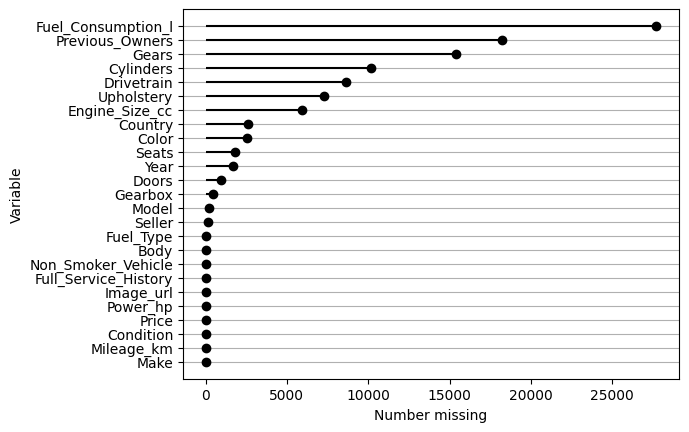

In [14]:
df.missing.missing_variable_plot()

<Axes: >

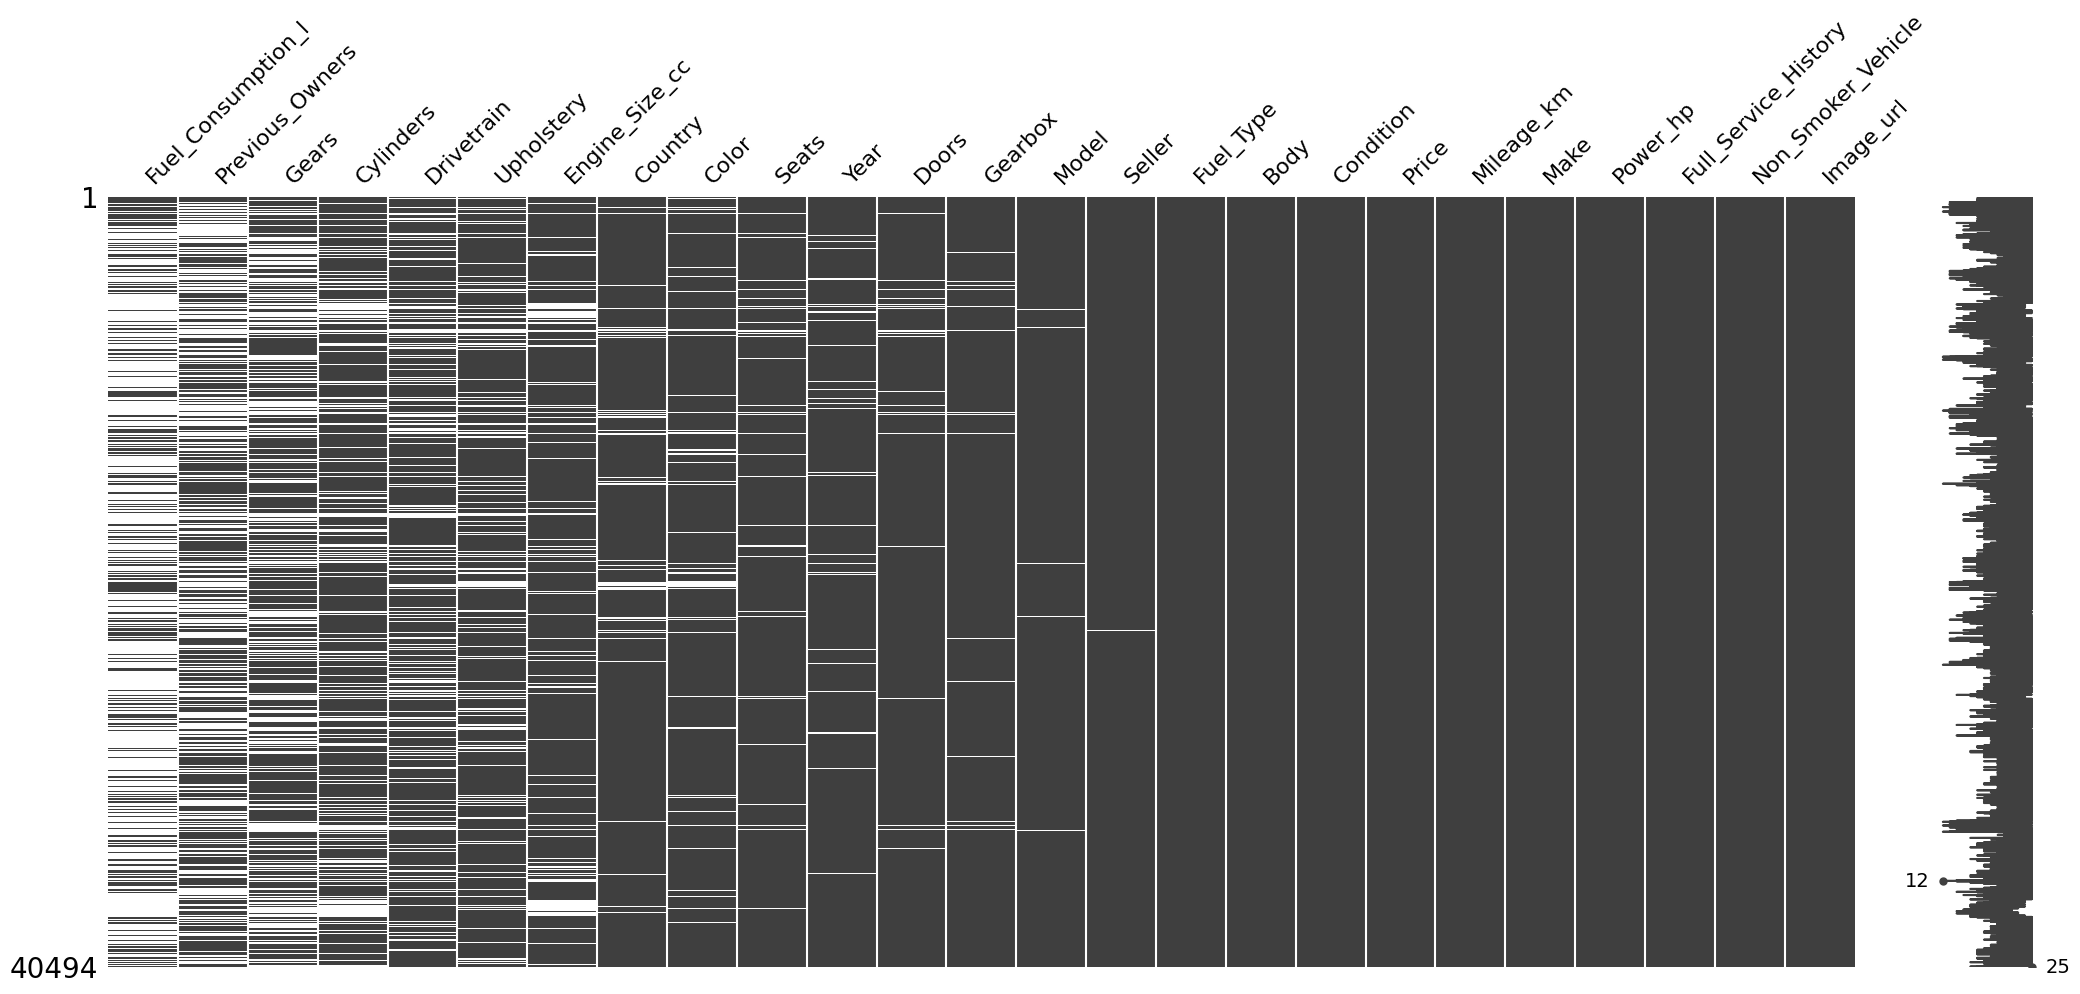

In [15]:
import missingno

df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [16]:
df.dtypes

,0
Make,object
Model,object
Body,object
Mileage_km,int64
Price,int64
Year,float64
Country,object
Condition,object
Fuel_Type,object
Fuel_Consumption_l,float64


In [37]:
numerics_nan = ['Fuel_Consumption_l','Previous_Owners','Gears','Cylinders','Engine_Size_cc','Seats','Year','Doors']

In [38]:
df_cleaned = df.copy()

In [39]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

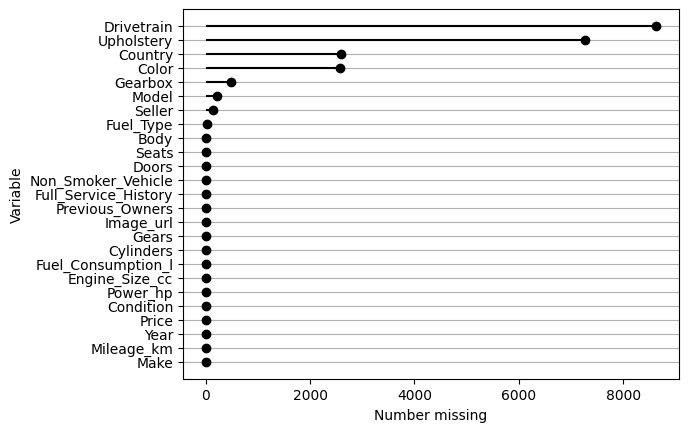

In [40]:
df_cleaned.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES CATEGORICAS

In [41]:
objects_nan = ['Fuel_Type','Body','Drivetrain','Upholstery','Country','Color','Gearbox','Model','Seller']

In [42]:
for variable in objects_nan:
  df_cleaned[variable] = df_cleaned[variable].ffill()
  df_cleaned[variable] = df_cleaned[variable].bfill()


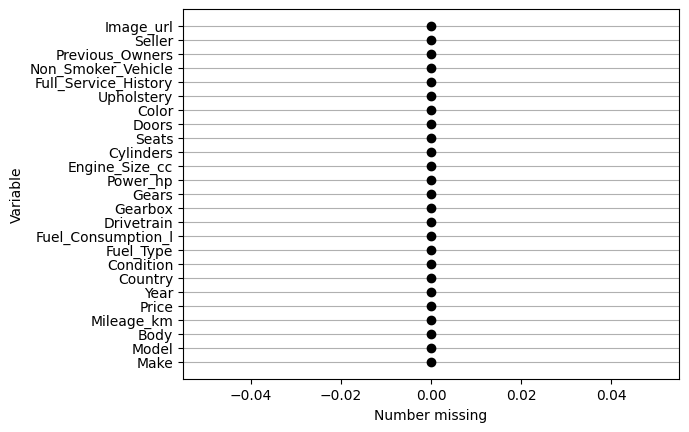

In [43]:
df_cleaned.missing.missing_variable_plot()

In [44]:
df_cleaned.missing.number_missing()

np.int64(0)

In [45]:
df_cleaned.shape

(40494, 25)

In [31]:
df_cleaned.describe()

,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Previous_Owners
count,4.049400e+04,4.049400e+04,40494.000000,40494.000000,40494.000000,40494.000000,40494.000000,40494.000000,40494.000000,40494.000000,40494.000000
mean,7.723058e+04,5.662527e+04,2017.406134,6.913935,5.937373,231.339976,2275.072208,4.785277,4.649923,4.244826,1.223465
std,3.216313e+05,1.820272e+05,8.948187,1.994668,1.585947,179.923677,1423.674452,1.909660,1.616883,1.100811,0.788297
min,0.000000e+00,1.000000e+00,1922.000000,0.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,1.700000e+04,1.368350e+04,2016.000000,7.000000,6.000000,116.000000,1395.000000,4.000000,5.000000,4.000000,1.000000
50%,5.599500e+04,2.219950e+04,2020.000000,7.000000,6.000000,158.000000,1984.000000,4.000000,5.000000,5.000000,1.000000
75%,1.059982e+05,3.600000e+04,2023.000000,7.000000,6.000000,280.000000,2275.000000,5.000000,5.000000,5.000000,1.000000
max,1.677722e+07,9.999999e+06,2026.000000,55.000000,69.000000,3399.000000,67500.000000,50.000000,255.000000,25.000000,94.000000


In [46]:
variable = 'Mileage_km'
data = df_cleaned[variable]

In [47]:
mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

📊 Medidas de tendencia central de Mileage_km
Media (μ): 77230.58
Mediana: 55995.00
Moda: 10.00


In [48]:
variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")


📈 Medidas de dispersión de Mileage_km
Varianza (σ²): 103446710094.77
Desviación estándar (σ): 321631.33
Rango: 16777215.00
Rango intercuartílico (IQR): 88998.25


In [49]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para Mileage_km
Límite inferior: -116497.38
Límite superior: 239495.62
Número de outliers detectados: 997


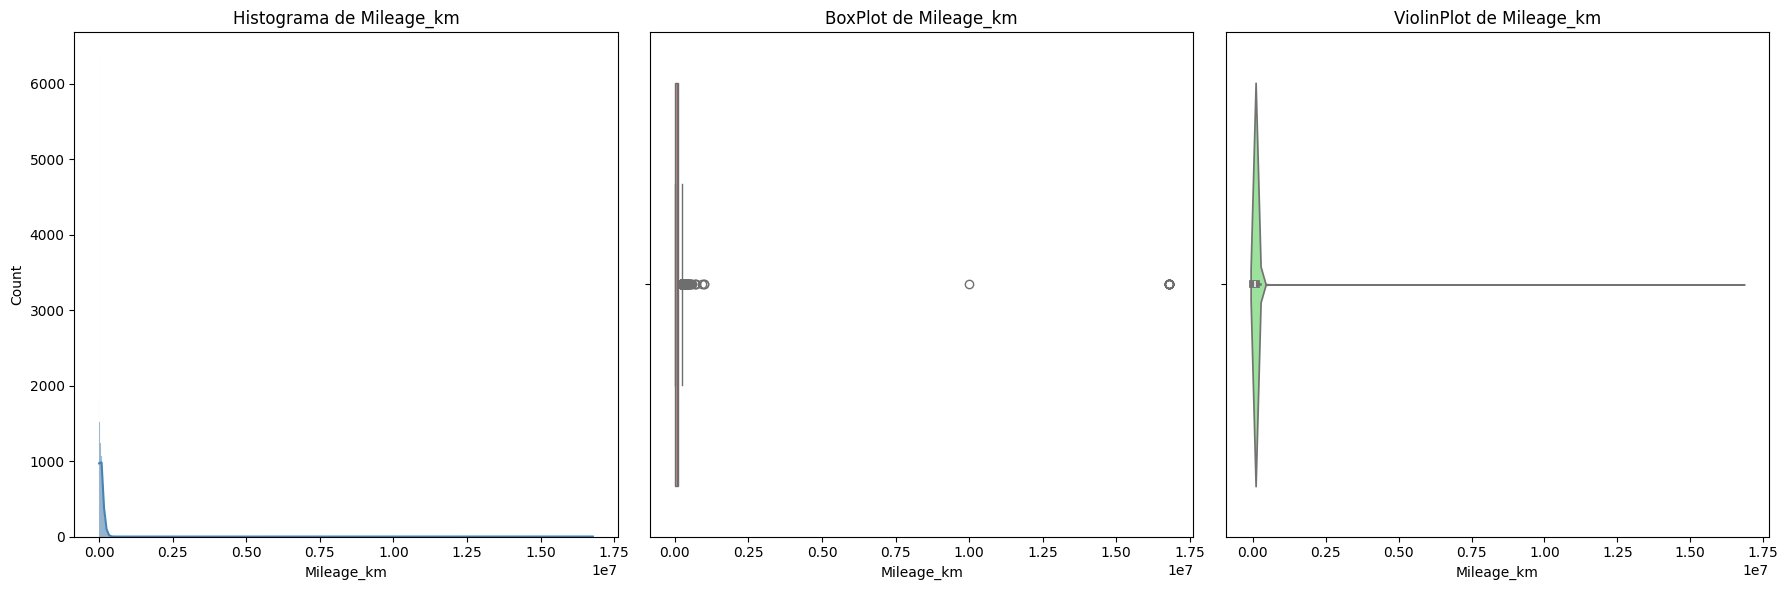

In [50]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

# CORRELACIONES

In [52]:
corr_matrix = df_cleaned.corr(numeric_only=True)
corr_price = corr_matrix[['Price']].sort_values(by='Price',ascending=False)
corr_price

,Price
Price,1.000000
Power_hp,0.468264
Cylinders,0.337319
Engine_Size_cc,0.326771
Fuel_Consumption_l,0.130321
Gears,0.090620
Year,0.013881
Full_Service_History,0.012564
Non_Smoker_Vehicle,-0.017670
Previous_Owners,-0.020816


<Axes: >

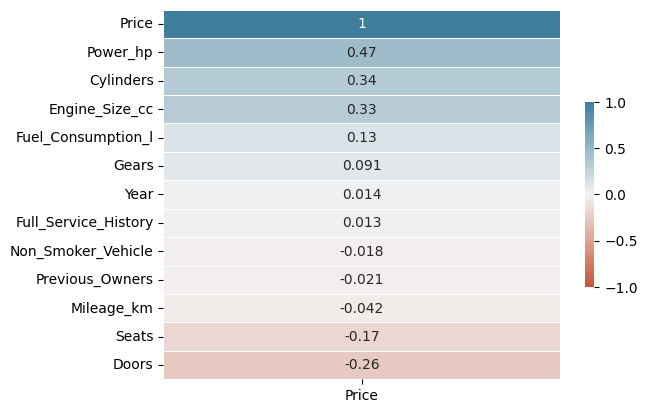

In [53]:
sns.heatmap(
    data=corr_price,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)

In [54]:
df_cleaned.to_csv('cars_cleaned.csv',index=None)

In [32]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [33]:
numeric_cols = df_cleaned.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df_cleaned = remove_outliers(df_cleaned, col)

print("Outliers removed from numeric columns. New shape of df_cleaned:", df_cleaned.shape)

Outliers removed from numeric columns. New shape of df_cleaned: (9366, 25)
